In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.signal import fftconvolve
from scipy.signal import convolve, deconvolve

In [2]:
name_array = ["IRF_1_nenir30_channel1_picus_60mW_1299.5nm_deadtime_20ns_same_as_lifetime.txt",
              "IRF_1_nenir30_channel1_picus_60mW_1299.5nm.txt",
              "Lifetime_3225_1296426_0.2mW_PID_0_signal_delay_no_filter_other_channel.txt",
              "Lifetime_3225_1296426_0.2mW_PID_0_signal_delay_no_filter.txt",
              "Lifetime_3225_1296426_0.2mW_PID_0_signal_delay.txt",
              "Lifetime_3225_1296426_0.2mW_PID.txt",
              "Lifetime_3225_1296426_10uW_PID_0_signal_delay_no_filter_other_channel.txt",
              "Dot_-03239V_129646_etalon_1_5_uW_power.txt"]

In [3]:
def find_peaks_sort(data, pre_window = 100, post_window = 200):
    normalized_y_axis = data[:,1] / np.max(data[:,1])
    peaks, properties = find_peaks(normalized_y_axis, height = 0.8)
    if len(peaks) > 0:
        first_peak_index = peaks[0]
        start = first_peak_index - pre_window
        end = first_peak_index + post_window
        isolated_data = data[start:end]
    return  isolated_data

C:\Users\emile\AppData\Local\Temp\ipykernel_24144\3434297716.py:79: OptimizeWarning: Covariance of the parameters could not be estimated
  params, cov = curve_fit(reconvolution_model_norm, t_life_shifted, normalized_y_life, p0=p0)


Fitted tau = 94.49 ps
second_tau = 200.0 ps 


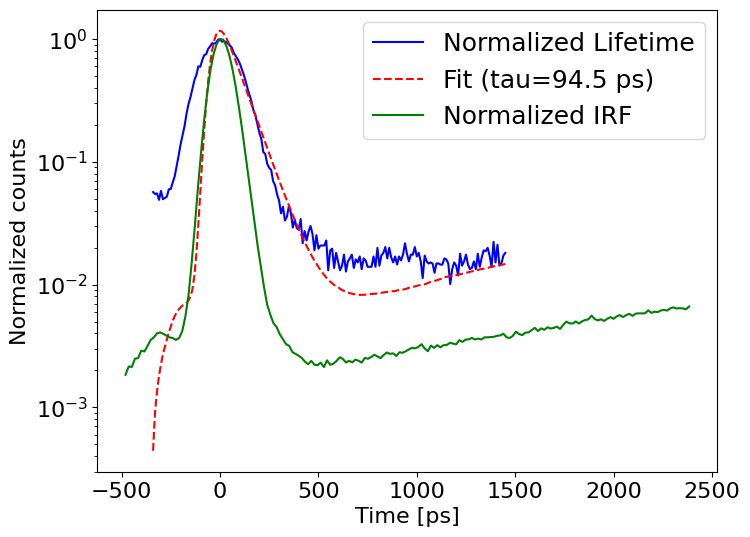

In [4]:
irf_data = np.loadtxt("lifetime_data/IRF_1_nenir30_channel1_picus_60mW_1299.5nm.txt", skiprows=1)
lifetime_data = np.loadtxt("lifetime_data/Dot_-03239V_129646_etalon_1_5_uW_power.txt", skiprows=1)

irf_data = find_peaks_sort(irf_data, pre_window = 30, post_window = 150)
lifetime_data = find_peaks_sort(lifetime_data, pre_window = 30, post_window = 150)


# x-axes
t_irf = irf_data[:,0]
t_life = lifetime_data[:,0]

# y-axes
y_irf = irf_data[:,1]
y_life = lifetime_data[:,1]

# First we shift the data 

irf_peak_index = np.argmax(y_irf)
t0_irf = t_irf[irf_peak_index]

lifetime_peak_index = np.argmax(y_life)
t0_lifetime = t_life[lifetime_peak_index]


t_irf_shifted = t_irf - t0_irf 
t_life_shifted = t_life - t0_lifetime



# Cutting the data at the same place on the x axis. 

t_min = np.min(t_life_shifted)
t_max = np.max(t_life_shifted)

# Mask IRF data to keep only points within lifetime x-axis range
mask = (t_irf_shifted >= t_min) & (t_irf_shifted <= t_max)  
t_irf_cut = t_irf_shifted[mask]
y_irf_cut = y_irf[mask]


def min_max_normalize(data):
    return (data-np.min(data))/(np.max(data)-np.min(data))



#normalized_y_irf = min_max_normalize(y_irf)
#normalized_y_irf = min_max_normalize(y_irf_cut)
#normalized_y_life = min_max_normalize(y_life)

normalized_y_irf = y_irf / np.max(y_irf)
normalized_y_life = y_life / np.max(y_life)


def exp_decay(t, I0, t0, tau):
    return I0 * np.exp(-(t - t0) / tau) * (t >= t0)

def reconvolution_model_norm(t, t_shift, I0, tau0, t0, I1, tau1, t1):
    #decay = I0 * np.exp(-t / tau) 
    decay = exp_decay(t, I0, t0, tau0)
    decay_2 = exp_decay(t, I1, t1, tau1)

    total_signal = decay #  + decay_2
    conv = (convolve(normalized_y_irf, total_signal, mode='full', method = "fft")/np.trapezoid(normalized_y_irf)) [:len(t)] 
     
    dt = t[1] - t[0]
    return conv * dt # I0 *

I0 = 1 * 10**(-3)
tau0_guess = 170.0
t0_guess = -1500
I1 = I0 
tau1_guess = 200
t1_guess = -1500
t_shift = 0

p0 = np.array([I0, t_shift, tau0_guess, t0_guess, I1, tau1_guess, t1_guess])


params, cov = curve_fit(reconvolution_model_norm, t_life_shifted, normalized_y_life, p0=p0) 


print(f"Fitted tau = {params[2]:.2f} ps")
print(f"second_tau = {params[5]} ps ")

plt.figure(figsize=(8, 6))
plt.plot(t_life_shifted, normalized_y_life, label='Normalized Lifetime', color='blue')
plt.plot(t_life_shifted, reconvolution_model_norm(t_life_shifted, *params), '--', color='red', label=f'Fit (tau={params[2]:.1f} ps)')
plt.plot(t_irf_shifted, normalized_y_irf, "-", color = "green", label = f"Normalized IRF")
#plt.plot(t_irf_shifted ,reconvolution_model_norm(t_irf_shifted, *params), label = "convolution guess", color = "black")
plt.xlabel('Time [ps]', fontsize = 16)
plt.ylabel('Normalized counts', fontsize = 16)
#plt.title('Normalized Lifetime Fit with IRF Convolution')
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.yscale("log")
plt.legend(fontsize = 18)
plt.savefig("lifetime_fit.png", dpi = 300)
plt.show()

The lifetime is comprised here is a combination of laser light and emission from the quantum dot, and can therefore not be utilized and has to be retaken.